## Ячейка 1 — TensorFlow и GPU

In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

if not tf.config.list_physical_devices("GPU"):
    raise RuntimeError("GPU was not found. Enable Accelerator -> GPU.")

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Ячейка 2 — автоматический поиск GTSRB и проектного кода

In [2]:
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")


def find_gtsrb_root() -> Path:
    # Find the GTSRB directory by checking its required structure.
    for train_csv in INPUT_ROOT.rglob("Train.csv"):
        candidate = train_csv.parent

        if (
            (candidate / "Test.csv").exists()
            and (candidate / "Train").is_dir()
            and (candidate / "Test").is_dir()
        ):
            return candidate

    raise FileNotFoundError("The GTSRB dataset root was not found.")


def find_code_root() -> Path:
    # Find the uploaded project directory containing code and manifests.
    for pipeline_file in INPUT_ROOT.rglob("data_pipeline.py"):
        candidate = pipeline_file.parent

        if (
            (candidate / "prepared_data" / "train_manifest.csv").exists()
            and (candidate / "prepared_data" / "validation_manifest.csv").exists()
        ):
            return candidate

    raise FileNotFoundError("The uploaded project code root was not found.")


DATASET_ROOT = find_gtsrb_root()
SOURCE_ROOT = find_code_root()

print("GTSRB root:", DATASET_ROOT)
print("Project code root:", SOURCE_ROOT)

GTSRB root: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
Project code root: /kaggle/input/datasets/yuriyrizoboyev/traffic-sign-project-code/Traffic_Sign_Kaggle


## Ячейка 3 — копирование кода в `/kaggle/working`

In [3]:
import shutil

PROJECT_ROOT = Path("/kaggle/working/traffic_sign_project")

# Remove an old working copy when the notebook is executed again.
if PROJECT_ROOT.exists():
    shutil.rmtree(PROJECT_ROOT)

# Copy the project code because /kaggle/input is read-only.
shutil.copytree(SOURCE_ROOT, PROJECT_ROOT)

PREPARED_ROOT = PROJECT_ROOT / "prepared_data"

print("Working project root:", PROJECT_ROOT)
print("Prepared data root:", PREPARED_ROOT)

Working project root: /kaggle/working/traffic_sign_project
Prepared data root: /kaggle/working/traffic_sign_project/prepared_data


## Ячейка 4 — проверка обязательных файлов

In [4]:
required_paths = [
    PROJECT_ROOT / "data_pipeline.py",
    PREPARED_ROOT / "train_manifest.csv",
    PREPARED_ROOT / "validation_manifest.csv",
    DATASET_ROOT / "Train.csv",
    DATASET_ROOT / "Test.csv",
    DATASET_ROOT / "Train",
    DATASET_ROOT / "Test",
]

missing_paths = []

for path in required_paths:
    if path.exists():
        print("OK:", path)
    else:
        print("MISSING:", path)
        missing_paths.append(path)

if missing_paths:
    raise FileNotFoundError(
        "Required files are missing:\n"
        + "\n".join(str(path) for path in missing_paths)
    )

print("\nAll required files were found.")

OK: /kaggle/working/traffic_sign_project/data_pipeline.py
OK: /kaggle/working/traffic_sign_project/prepared_data/train_manifest.csv
OK: /kaggle/working/traffic_sign_project/prepared_data/validation_manifest.csv
OK: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train.csv
OK: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test.csv
OK: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train
OK: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test

All required files were found.


## Ячейка 5 — конфигурация ConvNeXtTiny

In [5]:
config_text = r"""
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Literal


NormalizationMode = Literal[
    "zero_one",
    "minus_one_one",
    "none",
]


@dataclass(frozen=True)
class DataConfig:
    image_height: int = 224
    image_width: int = 224
    augmentation_resize: int = 240
    channels: int = 3
    number_of_classes: int = 43

    batch_size: int = 16
    shuffle_buffer: int = 10000
    random_seed: int = 42

    # ConvNeXt includes its own preprocessing and expects pixels in [0, 255].
    normalization_mode: NormalizationMode = "none"

    rotation_factor: float = 0.03
    translation_factor: float = 0.05
    zoom_factor: float = 0.08
    brightness_factor: float = 0.12
    contrast_factor: float = 0.12

    noise_probability: float = 0.15
    noise_stddev_255: float = 4.0
    blur_probability: float = 0.15

    deterministic_pipeline: bool = True

    @property
    def dataset_root(self) -> Path:
        return Path(r"__DATASET_ROOT__")

    @property
    def prepared_data_root(self) -> Path:
        return Path(r"__PREPARED_ROOT__")

    @property
    def train_manifest_path(self) -> Path:
        return self.prepared_data_root / "train_manifest.csv"

    @property
    def validation_manifest_path(self) -> Path:
        return self.prepared_data_root / "validation_manifest.csv"

    @property
    def test_manifest_path(self) -> Path:
        return self.dataset_root / "Test.csv"

    @property
    def output_root(self) -> Path:
        return Path("/kaggle/working/convnexttiny_outputs")

    @property
    def figure_root(self) -> Path:
        return self.output_root / "figures"

    @property
    def report_root(self) -> Path:
        return self.output_root / "reports"

    def to_serializable_dict(self) -> dict[str, object]:
        return {
            "dataset_root": str(self.dataset_root),
            "prepared_data_root": str(self.prepared_data_root),
            "train_manifest_path": str(self.train_manifest_path),
            "validation_manifest_path": str(self.validation_manifest_path),
            "test_manifest_path": str(self.test_manifest_path),
            "image_height": self.image_height,
            "image_width": self.image_width,
            "channels": self.channels,
            "number_of_classes": self.number_of_classes,
            "batch_size": self.batch_size,
            "random_seed": self.random_seed,
            "normalization_mode": self.normalization_mode,
        }
"""

config_text = config_text.replace(
    "__DATASET_ROOT__",
    str(DATASET_ROOT),
)
config_text = config_text.replace(
    "__PREPARED_ROOT__",
    str(PREPARED_ROOT),
)

config_path = PROJECT_ROOT / "config.py"
config_path.write_text(config_text, encoding="utf-8")

print("ConvNeXtTiny config created:", config_path)

ConvNeXtTiny config created: /kaggle/working/traffic_sign_project/config.py


## Ячейка 6 — импорт pipeline

In [6]:
import importlib
import sys

project_path = str(PROJECT_ROOT)

# Add the working project directory to Python search paths.
if project_path not in sys.path:
    sys.path.insert(0, project_path)

# Remove previously imported project modules.
for module_name in ["config", "data_pipeline"]:
    sys.modules.pop(module_name, None)

importlib.invalidate_caches()

from config import DataConfig
import data_pipeline

print("Config module:", sys.modules["config"].__file__)
print("Data pipeline module:", data_pipeline.__file__)
print(
    "build_all_datasets available:",
    hasattr(data_pipeline, "build_all_datasets"),
)

if not hasattr(data_pipeline, "build_all_datasets"):
    raise AttributeError("build_all_datasets was not found in data_pipeline.py.")

Config module: /kaggle/working/traffic_sign_project/config.py
Data pipeline module: /kaggle/working/traffic_sign_project/data_pipeline.py
build_all_datasets available: True


## Ячейка 7 — создание datasets

In [7]:
import random
import numpy as np

RANDOM_SEED = 42

# Set reproducible random seeds.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

config = DataConfig(batch_size=16)
data = data_pipeline.build_all_datasets(config)

train_ds = data["train_dataset"]
validation_ds = data["validation_dataset"]
test_ds = data["test_dataset"]
class_weights = data["class_weights"]

print("Training images:", len(data["train_frame"]))
print("Validation images:", len(data["validation_frame"]))
print("Test images:", len(data["test_frame"]))
print("Class weights:", len(class_weights))

I0000 00:00:1784737275.588180      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Training images: 31372
Validation images: 7829
Test images: 12630
Class weights: 43


## Ячейка 8 — проверка диапазона и формы

In [8]:
images, labels = next(iter(train_ds))

pixel_minimum = float(tf.reduce_min(images).numpy())
pixel_maximum = float(tf.reduce_max(images).numpy())

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Pixel minimum:", pixel_minimum)
print("Pixel maximum:", pixel_maximum)

if images.shape[1:] != (224, 224, 3):
    raise ValueError(f"Unexpected image shape: {images.shape}")

if pixel_minimum < 0.0:
    raise ValueError("Negative pixel values were found.")

if pixel_maximum <= 1.01:
    raise ValueError(
        "The pipeline still returns [0, 1] pixels. "
        "ConvNeXt requires [0, 255] when preprocessing is included."
    )

if pixel_maximum > 255.01:
    raise ValueError("Pixel values exceed 255.")

Images shape: (16, 224, 224, 3)
Labels shape: (16,)
Pixel minimum: 0.0
Pixel maximum: 255.0


## Ячейка 9 — визуальная проверка

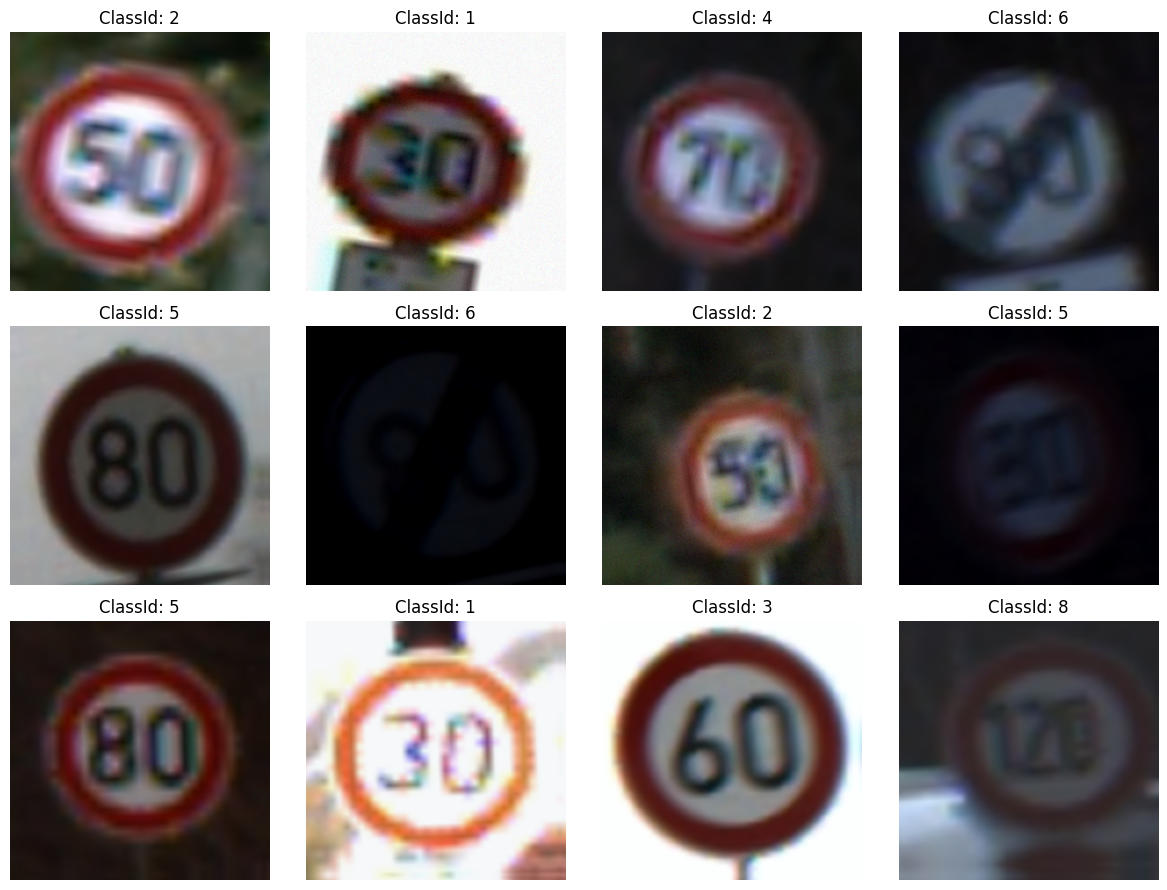

In [9]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(3, 4, figsize=(12, 9))

for index, axis in enumerate(axes.ravel()):
    image = images[index].numpy()
    image = np.clip(image, 0, 255).astype(np.uint8)

    axis.imshow(image)
    axis.set_title(f"ClassId: {int(labels[index])}")
    axis.axis("off")

plt.tight_layout()
plt.show()

## Ячейка 10 — функции создания и компиляции ConvNeXtTiny

In [10]:
def build_convnexttiny_model(
    input_shape=(224, 224, 3),
    number_of_classes=43,
):
    # Load the ImageNet-pretrained ConvNeXtTiny backbone.
    base_model = tf.keras.applications.ConvNeXtTiny(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape,
        include_preprocessing=True,
    )

    # Freeze the complete backbone for stage 1.
    base_model.trainable = False

    inputs = tf.keras.Input(
        shape=input_shape,
        name="image",
    )

    # Let Keras propagate the training mode to ConvNeXt layers.
    x = base_model(inputs)

    x = tf.keras.layers.GlobalAveragePooling2D(
        name="global_average_pool",
    )(x)

    x = tf.keras.layers.LayerNormalization(
        epsilon=1e-6,
        name="classifier_layer_norm",
    )(x)

    x = tf.keras.layers.Dropout(
        0.30,
        name="classifier_dropout_1",
    )(x)

    x = tf.keras.layers.Dense(
        256,
        activation=tf.keras.activations.gelu,
        name="classifier_dense",
    )(x)

    x = tf.keras.layers.Dropout(
        0.30,
        name="classifier_dropout_2",
    )(x)

    outputs = tf.keras.layers.Dense(
        number_of_classes,
        activation="softmax",
        dtype="float32",
        name="class_probabilities",
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="convnexttiny_gtsrb",
    )

    return model, base_model


def compile_convnexttiny(
    model,
    learning_rate,
    weight_decay,
):
    # AdamW applies decoupled weight decay.
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        clipnorm=1.0,
    )

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(
                name="sparse_accuracy",
            ),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(
                k=3,
                name="top3_accuracy",
            ),
        ],
    )


def count_trainable_parameters(model) -> int:
    # Count parameters that will be updated by the optimizer.
    return int(
        sum(np.prod(weight.shape) for weight in model.trainable_weights)
    )

## Ячейка 11 — smoke test

In [11]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_SEED)

smoke_model, smoke_base_model = build_convnexttiny_model()
compile_convnexttiny(
    smoke_model,
    learning_rate=1e-3,
    weight_decay=1e-4,
)

smoke_history = smoke_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=1,
    steps_per_epoch=5,
    validation_steps=2,
    class_weight=class_weights,
    verbose=1,
)

print("ConvNeXtTiny smoke test completed.")

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 2.3643 - sparse_accuracy: 0.0139 - top3_accuracy: 0.0729     

I0000 00:00:1784737302.703081      66 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - loss: 2.1859 - sparse_accuracy: 0.0625 - top3_accuracy: 0.2000 - val_loss: 4.6470 - val_sparse_accuracy: 0.0000e+00 - val_top3_accuracy: 0.0000e+00
ConvNeXtTiny smoke test completed.


## Ячейка 12 — создание папок результатов

In [12]:
OUTPUT_ROOT = Path("/kaggle/working/convnexttiny_outputs")
MODEL_DIR = OUTPUT_ROOT / "models"
REPORT_DIR = OUTPUT_ROOT / "reports"
FIGURE_DIR = OUTPUT_ROOT / "figures"
LOG_DIR = OUTPUT_ROOT / "logs"

for directory in [MODEL_DIR, REPORT_DIR, FIGURE_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Results will be saved to:", OUTPUT_ROOT)

Results will be saved to: /kaggle/working/convnexttiny_outputs


## Ячейка 13 — чистая модель для полного обучения

In [13]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_SEED)

model, base_model = build_convnexttiny_model()
compile_convnexttiny(
    model,
    learning_rate=1e-3,
    weight_decay=1e-4,
)

print("Total parameters:", model.count_params())
print(
    "Trainable parameters at stage 1:",
    count_trainable_parameters(model),
)

Total parameters: 28029579
Trainable parameters at stage 1: 209451


## Ячейка 14 — сохранение архитектуры

In [14]:
model_summary_lines = []

model.summary(
    print_fn=model_summary_lines.append,
    expand_nested=True,
)

model_summary_text = "\n".join(model_summary_lines)
(REPORT_DIR / "model_summary.txt").write_text(
    model_summary_text,
    encoding="utf-8",
)

print(model_summary_text)

Model: "convnexttiny_gtsrb"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer (InputLayer)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └                            │ (None, 224, 224, 3)    │             0 │
│ convnext_tiny_prestem_normaliz… │                        │               │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼─────────────

## Ячейка 15 — callbacks Stage 1

In [15]:
stage1_weights_path = MODEL_DIR / "best_frozen_head.weights.h5"

stage1_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(stage1_weights_path),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(
        filename=str(LOG_DIR / "stage1_training_log.csv"),
        append=False,
    ),
    tf.keras.callbacks.TerminateOnNaN(),
]

## Ячейка 16 — Stage 1: обучение classifier head

In [16]:
import time

stage1_start = time.perf_counter()

history_stage1 = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=stage1_callbacks,
    verbose=1,
)

stage1_seconds = time.perf_counter() - stage1_start

print("Stage 1 training time, minutes:", stage1_seconds / 60)

Epoch 1/10
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 1.2710 - sparse_accuracy: 0.4932 - top3_accuracy: 0.7617
Epoch 1: val_loss improved from None to 1.26059, saving model to /kaggle/working/convnexttiny_outputs/models/best_frozen_head.weights.h5

Epoch 1: finished saving model to /kaggle/working/convnexttiny_outputs/models/best_frozen_head.weights.h5
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 386s 188ms/step - loss: 1.5451 - sparse_accuracy: 0.5559 - top3_accuracy: 0.8011 - val_loss: 1.2606 - val_sparse_accuracy: 0.5925 - val_top3_accuracy: 0.8394 - learning_rate: 0.0010
Epoch 2/10
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 0.6599 - sparse_accuracy: 0.6904 - top3_accuracy: 0.9113
Epoch 2: val_loss improved from 1.26059 to 1.04902, saving model to /kaggle/working/convnexttiny_outputs/models/best_frozen_head.weights.h5

Epoch 2: finished saving model to /kaggle/working/convnexttiny_outputs/models/best_frozen_head.weights.h5
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 332s 169ms/step - loss:

## Ячейка 17 — подготовка Stage 2 fine-tuning

In [17]:
# Restore the best classifier-head weights before fine-tuning.
model.load_weights(stage1_weights_path)

# Unfreeze only the final part of the ConvNeXtTiny backbone.
base_model.trainable = True
number_of_backbone_layers = len(base_model.layers)
number_of_fine_tuned_layers = 40
fine_tune_from = max(
    0,
    number_of_backbone_layers - number_of_fine_tuned_layers,
)

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_from:]:
    layer.trainable = True

# Recompile after changing the trainable flags.
compile_convnexttiny(
    model,
    learning_rate=1e-5,
    weight_decay=1e-5,
)

print("Total backbone layers:", number_of_backbone_layers)
print("Fine-tuning starts from layer:", fine_tune_from)
print(
    "Trainable parameters at stage 2:",
    count_trainable_parameters(model),
)

Total backbone layers: 133
Fine-tuning starts from layer: 93
Trainable parameters at stage 2: 18676011


## Ячейка 18 — callbacks Stage 2

In [18]:
best_model_path = MODEL_DIR / "best_convnexttiny.keras"

stage2_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(best_model_path),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(
        filename=str(LOG_DIR / "stage2_finetuning_log.csv"),
        append=False,
    ),
    tf.keras.callbacks.TerminateOnNaN(),
]

## Ячейка 19 — Stage 2: fine-tuning

In [19]:
completed_stage1_epochs = len(history_stage1.history["loss"])
additional_fine_tuning_epochs = 15

stage2_start = time.perf_counter()

history_stage2 = model.fit(
    train_ds,
    validation_data=validation_ds,
    initial_epoch=completed_stage1_epochs,
    epochs=completed_stage1_epochs + additional_fine_tuning_epochs,
    class_weight=class_weights,
    callbacks=stage2_callbacks,
    verbose=1,
)

stage2_seconds = time.perf_counter() - stage2_start

print("Stage 2 training time, minutes:", stage2_seconds / 60)

Epoch 11/25


2026-07-22 17:16:03.578885: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 17:16:03.754701: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 17:16:03.992515: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 17:16:04.185991: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1960/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - loss: 0.2365 - sparse_accuracy: 0.8722 - top3_accuracy: 0.9800

2026-07-22 17:22:21.212670: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 17:22:21.388546: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 17:22:21.622832: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 17:22:21.816663: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1961/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 0.2365 - sparse_accuracy: 0.8722 - top3_accuracy: 0.9800
Epoch 11: val_loss improved from None to 0.54971, saving model to /kaggle/working/convnexttiny_outputs/models/best_convnexttiny.keras

Epoch 11: finished saving model to /kaggle/working/convnexttiny_outputs/models/best_convnexttiny.keras
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 440s 209ms/step - loss: 0.2335 - sparse_accuracy: 0.9095 - top3_accuracy: 0.9862 - val_loss: 0.5497 - val_sparse_accuracy: 0.8425 - val_top3_accuracy: 0.9622 - learning_rate: 1.0000e-05
Epoch 12/25
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - loss: 0.1459 - sparse_accuracy: 0.9233 - top3_accuracy: 0.9903
Epoch 12: val_loss improved from 0.54971 to 0.44132, saving model to /kaggle/working/convnexttiny_outputs/models/best_convnexttiny.keras

Epoch 12: finished saving model to /kaggle/working/convnexttiny_outputs/models/best_convnexttiny.keras
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 389s 198ms/step - loss: 0.1513 - sparse_a

## Ячейка 20 — сохранение финальной модели и истории

In [20]:
import json
import pandas as pd

final_model_path = MODEL_DIR / "final_convnexttiny.keras"
model.save(final_model_path)

stage1_frame = pd.DataFrame(history_stage1.history)
stage1_frame.insert(
    0,
    "epoch",
    [epoch + 1 for epoch in history_stage1.epoch],
)
stage1_frame["phase"] = "frozen_backbone"

stage2_frame = pd.DataFrame(history_stage2.history)
stage2_frame.insert(
    0,
    "epoch",
    [epoch + 1 for epoch in history_stage2.epoch],
)
stage2_frame["phase"] = "fine_tuning"

history_frame = pd.concat(
    [stage1_frame, stage2_frame],
    ignore_index=True,
)

history_frame.to_csv(
    REPORT_DIR / "training_history.csv",
    index=False,
)

training_summary = {
    "stage1_epochs": int(len(stage1_frame)),
    "stage2_epochs": int(len(stage2_frame)),
    "stage1_minutes": float(stage1_seconds / 60),
    "stage2_minutes": float(stage2_seconds / 60),
    "best_val_loss": float(history_frame["val_loss"].min()),
    "best_val_accuracy": float(
        history_frame["val_sparse_accuracy"].max()
    ),
    "best_val_top3_accuracy": float(
        history_frame["val_top3_accuracy"].max()
    ),
    "total_parameters": int(model.count_params()),
    "fine_tuned_backbone_layers": int(number_of_fine_tuned_layers),
    "batch_size": int(config.batch_size),
}

(REPORT_DIR / "training_summary.json").write_text(
    json.dumps(training_summary, indent=2),
    encoding="utf-8",
)

print(json.dumps(training_summary, indent=2))

{
  "stage1_epochs": 10,
  "stage2_epochs": 15,
  "stage1_minutes": 53.679984295766666,
  "stage2_minutes": 101.97224211875,
  "best_val_loss": 0.28362345695495605,
  "best_val_accuracy": 0.9427768588066101,
  "best_val_top3_accuracy": 0.9890152215957642,
  "total_parameters": 28029579,
  "fine_tuned_backbone_layers": 40,
  "batch_size": 16
}


## Ячейка 21 — графики обучения

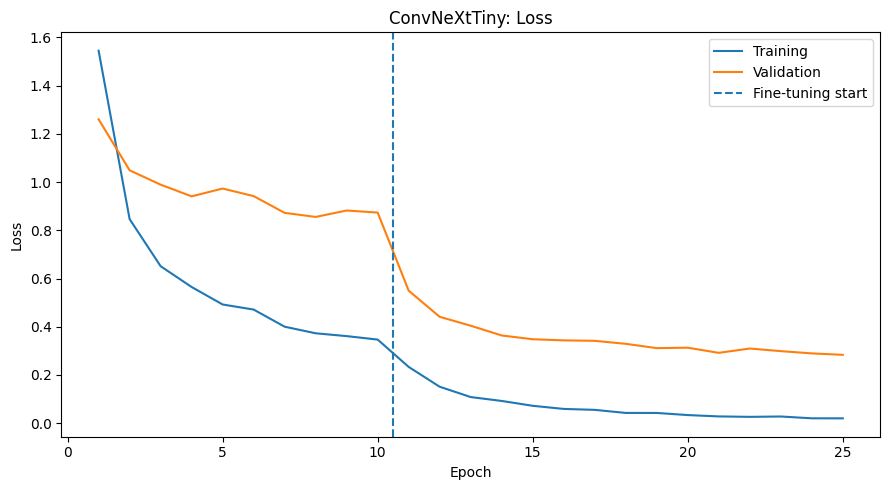

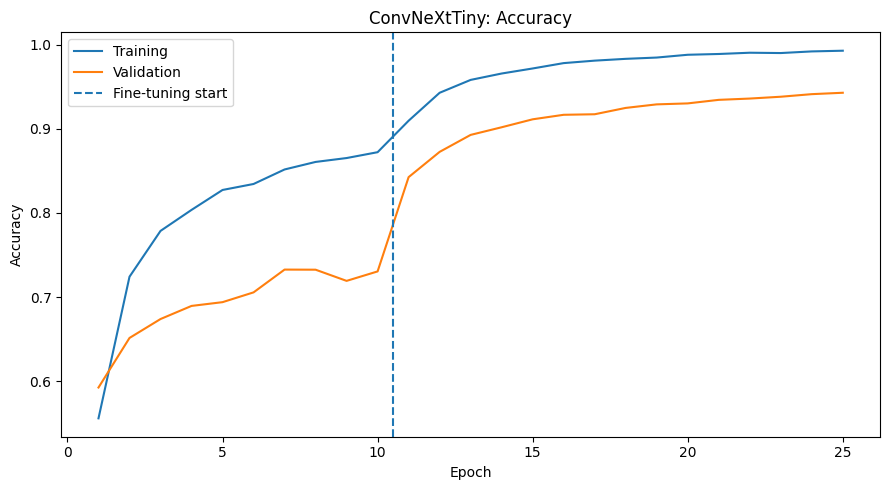

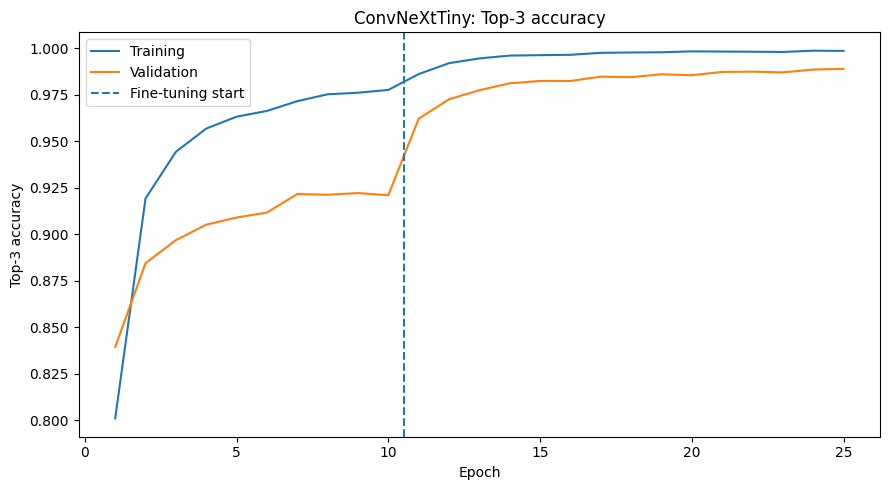

In [21]:
import matplotlib.pyplot as plt


def save_training_plot(
    training_column,
    validation_column,
    title,
    filename,
):
    # Validate that the required history columns exist.
    required_columns = [
        "epoch",
        training_column,
        validation_column,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in history_frame.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing history columns: {missing_columns}"
        )

    # Plot training and validation metrics across both stages.
    plt.figure(figsize=(9, 5))

    plt.plot(
        history_frame["epoch"],
        history_frame[training_column],
        label="Training",
    )

    plt.plot(
        history_frame["epoch"],
        history_frame[validation_column],
        label="Validation",
    )

    # Mark the start of fine-tuning.
    plt.axvline(
        completed_stage1_epochs + 0.5,
        linestyle="--",
        label="Fine-tuning start",
    )

    plt.xlabel("Epoch")
    plt.ylabel(title)
    plt.title(f"ConvNeXtTiny: {title}")
    plt.legend()
    plt.tight_layout()

    # Save figures in vector and raster formats.
    plt.savefig(
        FIGURE_DIR / f"{filename}.pdf",
        bbox_inches="tight",
    )

    plt.savefig(
        FIGURE_DIR / f"{filename}.png",
        dpi=160,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()


save_training_plot(
    "loss",
    "val_loss",
    "Loss",
    "convnexttiny_loss",
)

save_training_plot(
    "sparse_accuracy",
    "val_sparse_accuracy",
    "Accuracy",
    "convnexttiny_accuracy",
)

save_training_plot(
    "top3_accuracy",
    "val_top3_accuracy",
    "Top-3 accuracy",
    "convnexttiny_top3_accuracy",
)

## Ячейка 22 — загрузка и оценка лучшей модели

In [22]:
best_model = tf.keras.models.load_model(best_model_path)

test_evaluation = best_model.evaluate(
    test_ds,
    return_dict=True,
    verbose=1,
)

print("Keras test evaluation:")

for metric_name, metric_value in test_evaluation.items():
    print(f"{metric_name}: {metric_value:.6f}")

790/790 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - loss: 0.3271 - sparse_accuracy: 0.9349 - top3_accuracy: 0.9827
Keras test evaluation:
loss: 0.327125
sparse_accuracy: 0.934917
top3_accuracy: 0.982660


## Ячейка 23 — подробные test-метрики и скорость

In [23]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

# Run one warm-up batch before timing the complete test prediction.
warmup_images, _ = next(iter(test_ds.take(1)))
_ = best_model.predict(warmup_images, verbose=0)

prediction_start = time.perf_counter()
probabilities = best_model.predict(test_ds, verbose=1)
prediction_seconds = time.perf_counter() - prediction_start

true_labels = np.concatenate(
    [batch_labels.numpy() for _, batch_labels in test_ds]
)

predicted_labels = np.argmax(probabilities, axis=1)
confidence = np.max(probabilities, axis=1)

top3_classes = np.argsort(
    probabilities,
    axis=1,
)[:, -3:][:, ::-1]

top3_correct = np.any(
    top3_classes == true_labels[:, None],
    axis=1,
)

metrics = {
    "test_images": int(len(true_labels)),
    "accuracy": float(
        accuracy_score(true_labels, predicted_labels)
    ),
    "macro_precision": float(
        precision_score(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0,
        )
    ),
    "macro_recall": float(
        recall_score(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0,
        )
    ),
    "macro_f1": float(
        f1_score(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0,
        )
    ),
    "weighted_f1": float(
        f1_score(
            true_labels,
            predicted_labels,
            average="weighted",
            zero_division=0,
        )
    ),
    "top3_accuracy": float(top3_correct.mean()),
    "prediction_seconds": float(prediction_seconds),
    "milliseconds_per_image": float(
        prediction_seconds / len(true_labels) * 1000
    ),
    "images_per_second": float(
        len(true_labels) / prediction_seconds
    ),
    "parameter_count": int(best_model.count_params()),
    "model_file_size_mb": float(
        best_model_path.stat().st_size / (1024 * 1024)
    ),
    "keras_evaluate": {
        name: float(value)
        for name, value in test_evaluation.items()
    },
}

(REPORT_DIR / "test_metrics.json").write_text(
    json.dumps(metrics, indent=2),
    encoding="utf-8",
)

print(json.dumps(metrics, indent=2))

790/790 ━━━━━━━━━━━━━━━━━━━━ 44s 50ms/step
{
  "test_images": 12630,
  "accuracy": 0.934916864608076,
  "macro_precision": 0.9008417700978611,
  "macro_recall": 0.8864801164363855,
  "macro_f1": 0.89026064875076,
  "weighted_f1": 0.9350018077119181,
  "top3_accuracy": 0.9826603325415677,
  "prediction_seconds": 44.537182369998845,
  "milliseconds_per_image": 3.526301058590566,
  "images_per_second": 283.5832741971532,
  "parameter_count": 28029579,
  "model_file_size_mb": 249.96048545837402,
  "keras_evaluate": {
    "loss": 0.32712528109550476,
    "sparse_accuracy": 0.9349168539047241,
    "top3_accuracy": 0.9826603531837463
  }
}


## Ячейка 24 — classification report и слабые классы

In [24]:
class_report = classification_report(
    true_labels,
    predicted_labels,
    labels=list(range(43)),
    output_dict=True,
    zero_division=0,
)

class_report_frame = pd.DataFrame(class_report).transpose()
class_report_frame.to_csv(
    REPORT_DIR / "classification_report.csv"
)

class_rows = class_report_frame.loc[
    [str(class_id) for class_id in range(43)]
].copy()
class_rows.index = class_rows.index.astype(int)

worst_classes = class_rows.sort_values("f1-score").head(10)
worst_classes.to_csv(REPORT_DIR / "worst_classes.csv")

display(worst_classes)

,precision,recall,f1-score,support
37,0.227273,0.166667,0.192308,60.0
36,0.500000,0.666667,0.571429,120.0
34,0.588652,0.691667,0.636015,120.0
41,0.740000,0.616667,0.672727,60.0
39,0.906250,0.644444,0.753247,90.0
19,0.648352,0.983333,0.781457,60.0
33,0.778302,0.785714,0.781991,210.0
21,0.920000,0.766667,0.836364,90.0
0,1.000000,0.750000,0.857143,60.0
22,0.969388,0.791667,0.871560,120.0


## Ячейка 25 — confusion matrix и наиболее частые ошибки

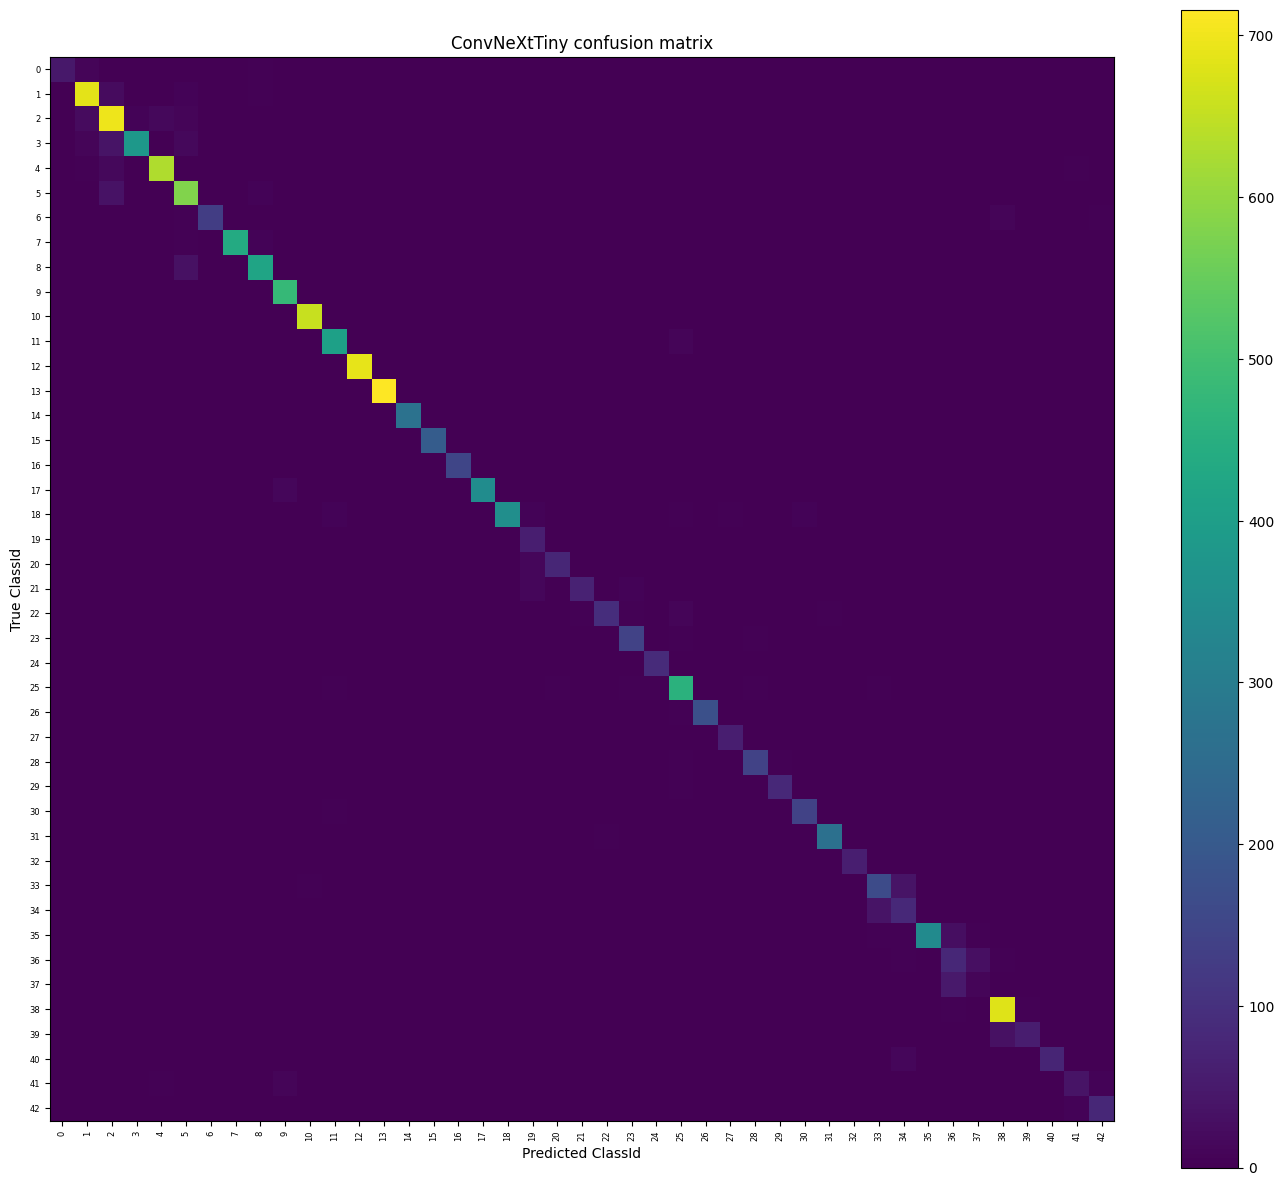

,true_class_id,predicted_class_id,count
131,37,36,48
12,3,2,38
109,33,34,38
113,34,33,37
24,5,2,35
136,39,38,32
38,8,5,31
128,36,37,29
119,35,36,27
7,2,1,21


In [25]:
confusion = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=list(range(43)),
)

confusion_frame = pd.DataFrame(
    confusion,
    index=[f"true_{class_id}" for class_id in range(43)],
    columns=[f"pred_{class_id}" for class_id in range(43)],
)
confusion_frame.to_csv(REPORT_DIR / "confusion_matrix.csv")

# Extract the largest off-diagonal confusion counts.
confusion_without_diagonal = confusion.copy()
np.fill_diagonal(confusion_without_diagonal, 0)

confusion_pairs = []
for true_class_id in range(43):
    for predicted_class_id in range(43):
        count = int(
            confusion_without_diagonal[
                true_class_id,
                predicted_class_id,
            ]
        )

        if count > 0:
            confusion_pairs.append(
                {
                    "true_class_id": true_class_id,
                    "predicted_class_id": predicted_class_id,
                    "count": count,
                }
            )

confusion_pairs_frame = pd.DataFrame(confusion_pairs)
confusion_pairs_frame = confusion_pairs_frame.sort_values(
    "count",
    ascending=False,
)
confusion_pairs_frame.to_csv(
    REPORT_DIR / "top_confusions.csv",
    index=False,
)

plt.figure(figsize=(14, 12))
plt.imshow(confusion)
plt.colorbar()
plt.xlabel("Predicted ClassId")
plt.ylabel("True ClassId")
plt.title("ConvNeXtTiny confusion matrix")
plt.xticks(range(43), rotation=90, fontsize=6)
plt.yticks(range(43), fontsize=6)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "convnexttiny_confusion_matrix.pdf",
    bbox_inches="tight",
)
plt.savefig(
    FIGURE_DIR / "convnexttiny_confusion_matrix.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

display(confusion_pairs_frame.head(20))

## Ячейка 26 — сохранение всех test-предсказаний

In [26]:
test_predictions = data["test_frame"][["Path", "ClassId"]].copy()
test_predictions = test_predictions.rename(
    columns={"ClassId": "true_class_id"}
)

test_predictions["predicted_class_id"] = predicted_labels
test_predictions["confidence"] = confidence
test_predictions["correct"] = (
    test_predictions["true_class_id"]
    == test_predictions["predicted_class_id"]
)

for rank in range(3):
    test_predictions[f"top{rank + 1}_class_id"] = top3_classes[:, rank]
    test_predictions[f"top{rank + 1}_probability"] = probabilities[
        np.arange(len(probabilities)),
        top3_classes[:, rank],
    ]

test_predictions.to_csv(
    REPORT_DIR / "test_predictions.csv",
    index=False,
)

display(test_predictions.head())

,Path,true_class_id,predicted_class_id,confidence,correct,top1_class_id,top1_probability,top2_class_id,top2_probability,top3_class_id,top3_probability
0,Test/00000.png,16,16,1.000000,True,16,1.000000,9,4.186749e-12,7,3.939438e-12
1,Test/00001.png,1,1,1.000000,True,1,1.000000,2,3.411736e-10,5,6.543652e-13
2,Test/00002.png,38,38,1.000000,True,38,1.000000,39,4.953075e-10,33,8.785784e-13
3,Test/00003.png,33,37,0.787413,False,37,0.787413,14,1.816399e-01,33,2.054166e-02
4,Test/00004.png,11,11,1.000000,True,11,1.000000,22,4.588403e-09,21,2.399171e-09


## Ячейка 27 — итоговая проверка и ZIP-архив

In [27]:
required_outputs = [
    MODEL_DIR / "best_convnexttiny.keras",
    MODEL_DIR / "final_convnexttiny.keras",
    REPORT_DIR / "model_summary.txt",
    REPORT_DIR / "training_history.csv",
    REPORT_DIR / "training_summary.json",
    REPORT_DIR / "test_metrics.json",
    REPORT_DIR / "classification_report.csv",
    REPORT_DIR / "worst_classes.csv",
    REPORT_DIR / "confusion_matrix.csv",
    REPORT_DIR / "top_confusions.csv",
    REPORT_DIR / "test_predictions.csv",
    FIGURE_DIR / "convnexttiny_loss.pdf",
    FIGURE_DIR / "convnexttiny_accuracy.pdf",
    FIGURE_DIR / "convnexttiny_top3_accuracy.pdf",
    FIGURE_DIR / "convnexttiny_confusion_matrix.pdf",
]

missing_outputs = []

for path in required_outputs:
    if path.exists():
        print("OK:", path)
    else:
        print("MISSING:", path)
        missing_outputs.append(path)

if missing_outputs:
    raise FileNotFoundError(
        "The ConvNeXtTiny outputs are incomplete:\n"
        + "\n".join(str(path) for path in missing_outputs)
    )

archive_path = shutil.make_archive(
    base_name="/kaggle/working/convnexttiny_results",
    format="zip",
    root_dir=OUTPUT_ROOT,
)

print("\nCONVNEXTTINY STAGE COMPLETED.")
print("Archive:", archive_path)

OK: /kaggle/working/convnexttiny_outputs/models/best_convnexttiny.keras
OK: /kaggle/working/convnexttiny_outputs/models/final_convnexttiny.keras
OK: /kaggle/working/convnexttiny_outputs/reports/model_summary.txt
OK: /kaggle/working/convnexttiny_outputs/reports/training_history.csv
OK: /kaggle/working/convnexttiny_outputs/reports/training_summary.json
OK: /kaggle/working/convnexttiny_outputs/reports/test_metrics.json
OK: /kaggle/working/convnexttiny_outputs/reports/classification_report.csv
OK: /kaggle/working/convnexttiny_outputs/reports/worst_classes.csv
OK: /kaggle/working/convnexttiny_outputs/reports/confusion_matrix.csv
OK: /kaggle/working/convnexttiny_outputs/reports/top_confusions.csv
OK: /kaggle/working/convnexttiny_outputs/reports/test_predictions.csv
OK: /kaggle/working/convnexttiny_outputs/figures/convnexttiny_loss.pdf
OK: /kaggle/working/convnexttiny_outputs/figures/convnexttiny_accuracy.pdf
OK: /kaggle/working/convnexttiny_outputs/figures/convnexttiny_top3_accuracy.pdf
OK: 